In [6]:
from math import sin, cos, pi, sqrt, exp

import numpy as np
import matplotlib.pyplot as plt

In [7]:
# All distances are in meters, pressure in pascals, force in newtons.
ATMOSPHERIC_PRESSURE = 101325  # Pa
GAMMA = 1.35                   # approximate specific heat ratio

# Finite combustion duration
COMBUSTION_PRESSURE_RISE = 3e6  # Pa, equivalent pressure increase
COMBUSTION_DURATION = 40 * pi / 180  # radians, burn duration
WIEBE_A = 6.9
WIEBE_M = 2.0

# Cylinder
CYLINDER_BORE = 0.108          # m, cylinder inside diameter
CYLINDER_STROKE = 0.0884       # m, piston travel distance
CYLINDER_ROD = 0.156           # m, connecting rod length
CYLINDER_CLEARANCE_HEIGHT = 0.012  # m, gas height above piston at TDC

# Crankshaft
RPM0 = 1000 # Initial engine speed
FLYWHEEL_INERTIA = 0.1 # kg*m^2, flywheel moment of inertia
LOAD_TORQUE = 10 # N*m, torque applied to the crankshaft by the load
FRICTION_TORQUE = 5 # N*m, torque applied to the crankshaft by friction

# Simulation
SIM_DT = 0.0001 # Time step
SIM_TIME = 0.2 # Simulation time

In [8]:
# Cylinder
piston_area = pi * (CYLINDER_BORE / 2) ** 2
clearance_volume = piston_area * CYLINDER_CLEARANCE_HEIGHT

# Crankshaft
crank_radius = CYLINDER_STROKE / 2

def calc_cylinder_volume(crank_angle):
    piston_height = (
        crank_radius * (1 - cos(crank_angle))
        + CYLINDER_ROD * (
            1 - sqrt(
                1 - (crank_radius / CYLINDER_ROD * sin(crank_angle)) ** 2
            )
        )
    )
    return clearance_volume + piston_area * piston_height

# Lowest position of the piston, highest volume
bdc_angle = pi
bdc_volume = calc_cylinder_volume(bdc_angle)
bdc_pressure = ATMOSPHERIC_PRESSURE

tdc_angle = 0
tdc_volume = calc_cylinder_volume(0)
tdc_pressure = ATMOSPHERIC_PRESSURE * (bdc_volume / tdc_volume) ** GAMMA # Before ignition

def calc_burn_fraction(crank_angle): # Wiebe heat-release curve for burned fraction
    if crank_angle > COMBUSTION_DURATION:
        return 1.0

    return 1 - exp(-WIEBE_A * (crank_angle / COMBUSTION_DURATION) ** (WIEBE_M + 1))

def calc_cylinder_pressure(crank_angle):
    volume = calc_cylinder_volume(crank_angle)

    if crank_angle < pi:
        # Expansion
        # return tdc_pressure * (tdc_volume / volume) ** GAMMA
        burn_fraction = calc_burn_fraction(crank_angle)
        return (tdc_pressure + burn_fraction * COMBUSTION_PRESSURE_RISE) * (tdc_volume / volume) ** GAMMA
    
    return bdc_pressure * (bdc_volume / volume) ** GAMMA

def calc_piston_force(crank_angle):
    pressure = calc_cylinder_pressure(crank_angle)
    cylinder_gauge_pressure = pressure - ATMOSPHERIC_PRESSURE

    return piston_area * cylinder_gauge_pressure

def calc_crank_torque(crank_angle):
    force = calc_piston_force(crank_angle)
    s, s2 = sin(crank_angle), sin(crank_angle*2)

    effective_lever_arm = crank_radius * (s+s2/2/sqrt((CYLINDER_ROD/crank_radius)**2 - s**2))
    
    return force * effective_lever_arm

In [9]:
N_steps = int(SIM_TIME / SIM_DT)

time_history = np.zeros(N_steps)
rpm_history = np.zeros(N_steps)
engine_torque_history = np.zeros(N_steps)
power_history = np.zeros(N_steps)

angular_velocity = RPM0 * 2 * pi / 60
crank_angle = 0.0
for step in range(N_steps):

    time = step * SIM_DT
    crank_angle_i = crank_angle % (2 * pi)

    engine_torque = calc_crank_torque(crank_angle_i)
    torque = engine_torque - LOAD_TORQUE - FRICTION_TORQUE

    angular_acceleration = torque / FLYWHEEL_INERTIA
    angular_velocity += angular_acceleration * SIM_DT
    crank_angle += angular_velocity * SIM_DT

    time_history[step] = step * SIM_DT
    rpm_history[step] = angular_velocity * 60 / (2 * pi)
    engine_torque_history[step] = engine_torque
    power_history[step] = engine_torque * angular_velocity

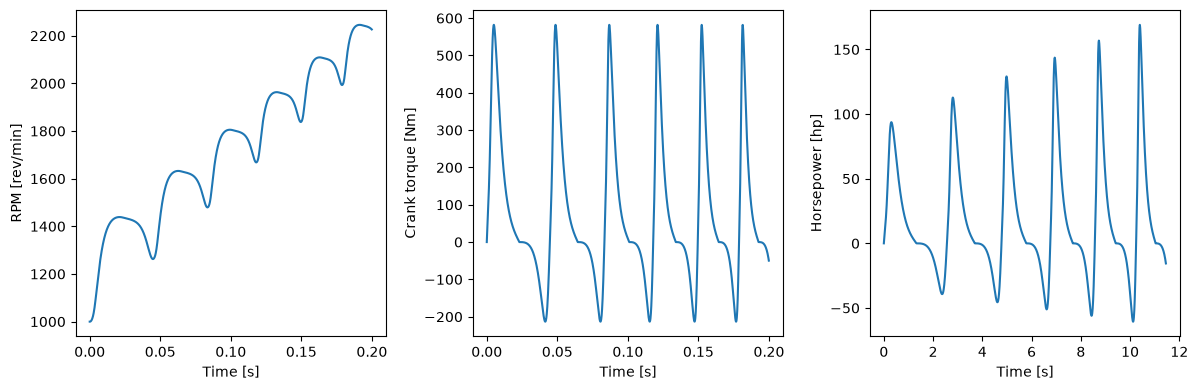

In [10]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# Crank angle at fixed RPM
ax = axes[0]
ax.set_xlabel('Time [s]') ; ax.set_ylabel('RPM [rev/min]')
ax.plot(time_history, rpm_history)

# Crank torque
ax = axes[1]
ax.set_xlabel('Time [s]') ; ax.set_ylabel('Crank torque [Nm]')
ax.plot(time_history, engine_torque_history)

# Instantaneous power
ax = axes[2]
ax.set_xlabel('Time [s]') ; ax.set_ylabel('Horsepower [hp]')
ax.plot(time_history*180/pi, power_history / 745.7)

plt.tight_layout()
plt.show()